In [1]:
import sys
sys.path.append('/Users/nagairyousuke/Documents/kashima_lab/master_paper')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_palette('husl')

# ========================================
# 正則化パラメータの設定
# ========================================
REG_TYPE = 'L1'      # 'L1', 'L2', 'None'
REG_LAMBDA = 1.0    # 0.001, 0.01, 0.1 など

# 正則化サフィックスの構築
if REG_TYPE.lower() in ['none', 'null']:
    reg_suffix = "no_reg"
else:
    reg_suffix = f"{REG_TYPE}_{REG_LAMBDA}"

print(f"分析対象: 正則化 {REG_TYPE}, λ={REG_LAMBDA}")
print(f"結果ディレクトリサフィックス: {reg_suffix}")
print("="*80)

分析対象: 正則化 L1, λ=1.0
結果ディレクトリサフィックス: L1_1.0


## 1. Load Results

In [2]:
# Load analysis results
analysis_dir = Path(f'../../analysis/assistments_2009_2010/{reg_suffix}')

print(f"読み込み元: {analysis_dir}")
print()

# ファイルの存在チェック
if not analysis_dir.exists():
    print(f"⚠️ 警告: ディレクトリが存在しません: {analysis_dir}")
    print(f"先に分析スクリプトを実行してください:")
    print(f"  python -m analysis.assistments_2009_2010.run_analysis --reg-type {REG_TYPE} --reg-lambda {REG_LAMBDA}")
else:
    stats_file = analysis_dir / 'statistics.csv'
    wins_file = analysis_dir / 'win_rates.csv'
    wilcoxon_file = analysis_dir / 'wilcoxon_results.csv'
    
    if not all([stats_file.exists(), wins_file.exists(), wilcoxon_file.exists()]):
        print(f"⚠️ 警告: 必要なファイルが不足しています")
        print(f"  statistics.csv: {stats_file.exists()}")
        print(f"  win_rates.csv: {wins_file.exists()}")
        print(f"  wilcoxon_results.csv: {wilcoxon_file.exists()}")
    else:
        df_stats = pd.read_csv(stats_file)
        df_wins = pd.read_csv(wins_file)
        df_wilcoxon = pd.read_csv(wilcoxon_file)
        
        print("Statistics:")
        display(df_stats)
        
        print("\nWin Rates:")
        display(df_wins)
        
        print("\nWilcoxon Test Results:")
        display(df_wilcoxon)

読み込み元: ../../analysis/assistments_2009_2010/L1_1.0

Statistics:


,dataset,method,n_samples,acc_mean,acc_std,spa_mean,spa_std,ace_mean,ace_std,mse_mean,mse_std
0,k5_L1_1.0,proposed,100,0.733636,0.088208,0.776832,0.043587,0.411128,0.082081,0.073825,0.015415
1,k5_L1_1.0,full_information,100,0.740076,0.087595,0.776807,0.043587,0.411104,0.082102,0.073850,0.015437
2,k5_L1_1.0,popularity,100,0.728333,0.083253,0.775675,0.044897,0.414566,0.085565,0.076137,0.017019
3,k5_L1_1.0,simple_markov,100,0.767045,0.078673,0.797951,0.049723,1.396808,1.050524,0.079283,0.021902
4,k5_L1_1.0,random,100,0.732500,0.082965,0.776811,0.043590,0.411147,0.082130,0.073839,0.015429
5,k10_L1_1.0,proposed,100,0.675369,0.096406,0.688252,0.048882,0.467133,0.098471,0.074288,0.013480
6,k10_L1_1.0,full_information,100,0.669571,0.097582,0.688206,0.048894,0.467219,0.098411,0.074306,0.013448
7,k10_L1_1.0,popularity,100,0.556774,0.092030,0.654047,0.053546,0.545401,0.113044,0.093626,0.016246
8,k10_L1_1.0,simple_markov,100,0.676679,0.087665,0.683028,0.059312,1.695951,1.221318,0.096570,0.021047
9,k10_L1_1.0,random,100,0.675750,0.089622,0.688231,0.048932,0.467152,0.098464,0.074292,0.013476



Win Rates:


,dataset,baseline,n_trials,acc_wins,acc_win_rate,spa_wins,spa_win_rate,ace_wins,ace_win_rate,mse_wins,mse_win_rate
0,k5_L1_1.0,full_information,100,45,0.45,51,0.51,51,0.51,52,0.52
1,k5_L1_1.0,popularity,100,45,0.45,51,0.51,54,0.54,67,0.67
2,k5_L1_1.0,simple_markov,100,36,0.36,25,0.25,80,0.80,60,0.60
3,k5_L1_1.0,random,100,42,0.42,56,0.56,52,0.52,57,0.57
4,k10_L1_1.0,full_information,100,52,0.52,55,0.55,55,0.55,56,0.56
5,k10_L1_1.0,popularity,100,95,0.95,100,1.00,100,1.00,100,1.00
6,k10_L1_1.0,simple_markov,100,44,0.44,54,0.54,85,0.85,98,0.98
7,k10_L1_1.0,random,100,46,0.46,55,0.55,54,0.54,54,0.54



Wilcoxon Test Results:


,dataset,metric,baseline,statistic,p_value,significant,alpha
0,k5_L1_1.0,acc,full_information,1939.5,6.680903e-01,False,0.05
1,k5_L1_1.0,spa,full_information,2664.0,3.163510e-01,False,0.05
2,k5_L1_1.0,ace,full_information,2459.0,5.897607e-01,False,0.05
3,k5_L1_1.0,mse,full_information,2822.0,1.535840e-01,False,0.05
4,k5_L1_1.0,acc,popularity,2273.5,2.374182e-01,False,0.05
5,k5_L1_1.0,spa,popularity,2923.0,8.558512e-02,False,0.05
6,k5_L1_1.0,ace,popularity,2978.0,5.966866e-02,False,0.05
7,k5_L1_1.0,mse,popularity,3842.0,2.973374e-06,True,0.05
8,k5_L1_1.0,acc,simple_markov,1484.0,9.995766e-01,False,0.05
9,k5_L1_1.0,spa,simple_markov,844.0,1.000000e+00,False,0.05


## 2. Performance Comparison (Mean ± Std)

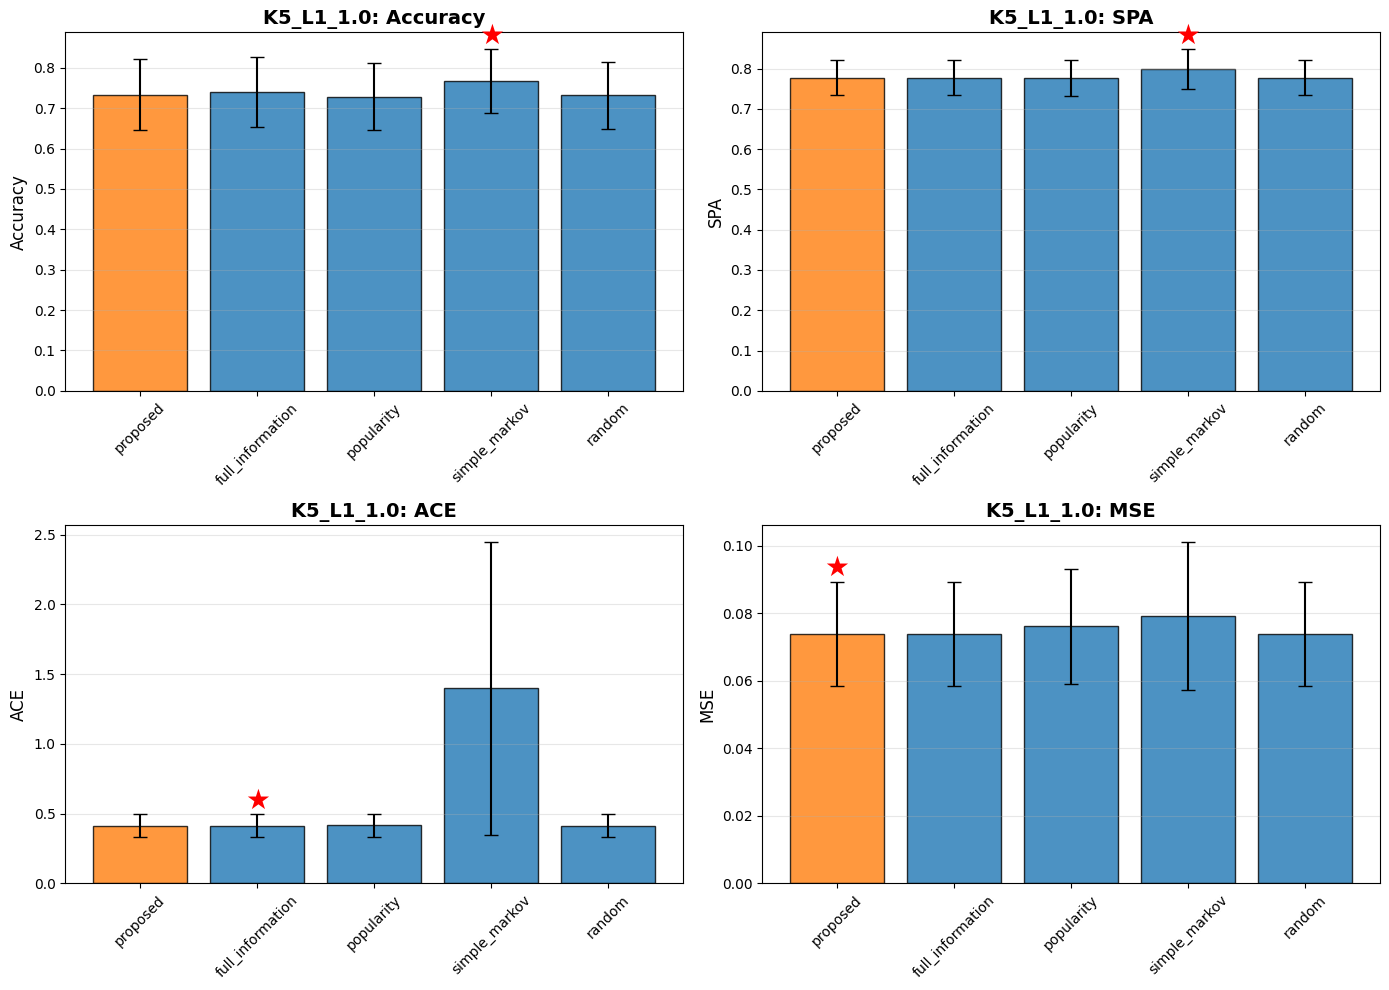

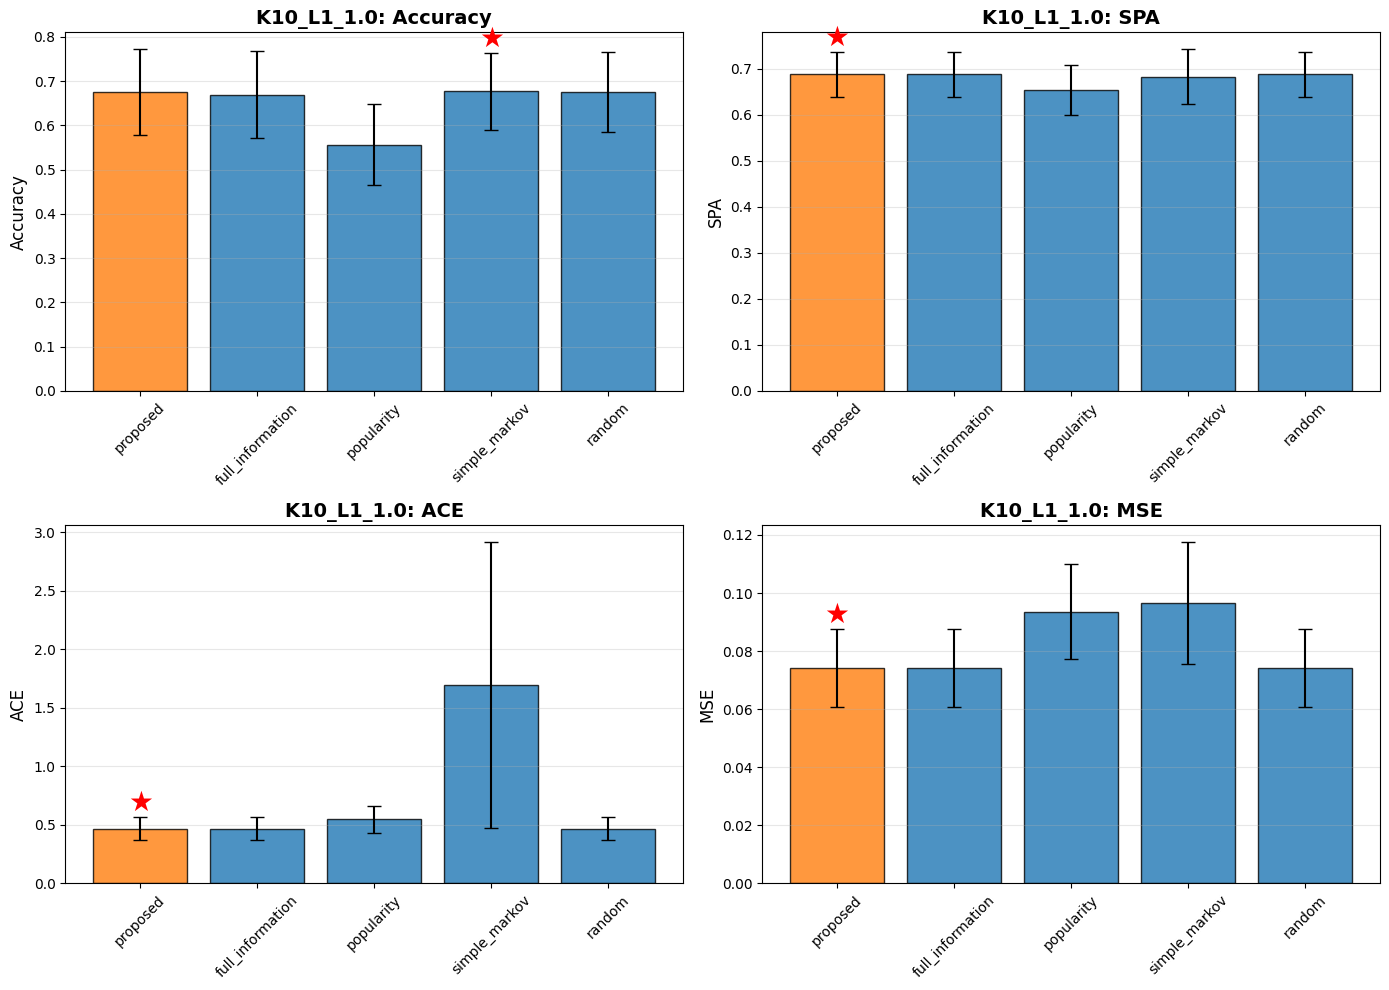

In [3]:
# Metrics to visualize
metrics = ['acc', 'spa', 'ace', 'mse']
metric_names = {
    'acc': 'Accuracy',
    'spa': 'SPA',
    'ace': 'ACE',
    'mse': 'MSE',
    'kl': 'KL Divergence',
    'hd': 'Hamming Distance',
    'jsd': 'JSD'
}

higher_is_better = {
    'acc': True,
    'spa': True,
    'ace': False,
    'mse': False,
    'kl': False,
    'hd': False,
    'jsd': False
}

for dataset in df_stats['dataset'].unique():
    df_dataset = df_stats[df_stats['dataset'] == dataset]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        methods = df_dataset['method'].values
        means = df_dataset[f'{metric}_mean'].values
        stds = df_dataset[f'{metric}_std'].values
        
        # Color proposed method differently
        colors = ['#ff7f0e' if m == 'proposed' else '#1f77b4' for m in methods]
        
        bars = ax.bar(methods, means, yerr=stds, capsize=5, alpha=0.8, color=colors, edgecolor='black')
        
        ax.set_ylabel(metric_names[metric], fontsize=12)
        ax.set_title(f'{dataset.upper()}: {metric_names[metric]}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)
        
        # Add best indicator
        if higher_is_better[metric]:
            best_idx = np.argmax(means)
        else:
            best_idx = np.argmin(means)
        
        ax.text(best_idx, means[best_idx] + stds[best_idx], '★', 
                ha='center', va='bottom', fontsize=20, color='red')
    
    plt.tight_layout()
    plt.show()

## 3. Win Rates Visualization

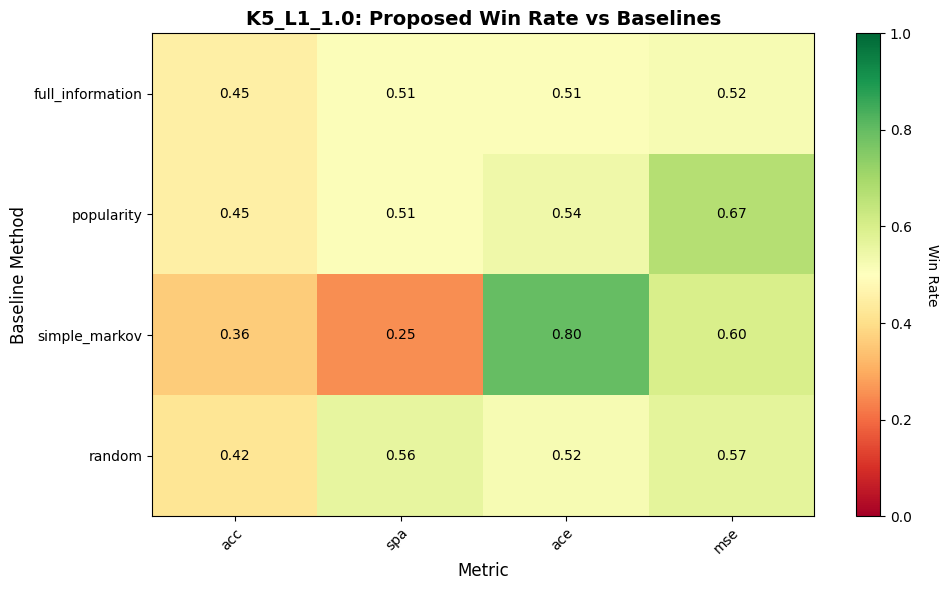

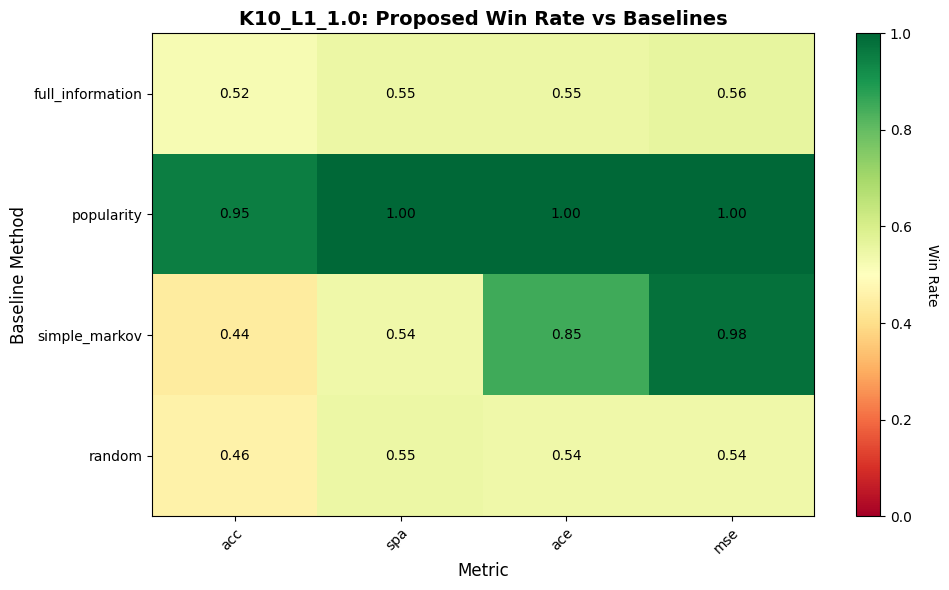

In [4]:
# Win rates heatmap
for dataset in df_wins['dataset'].unique():
    df_dataset = df_wins[df_wins['dataset'] == dataset]
    
    # Extract win rate columns
    win_rate_cols = [col for col in df_dataset.columns if col.endswith('_win_rate')]
    
    if not win_rate_cols:
        print(f"No win rate data for {dataset}")
        continue
    
    # Prepare data for heatmap
    baselines = df_dataset['baseline'].values
    metrics_for_heatmap = [col.replace('_win_rate', '') for col in win_rate_cols]
    
    win_rate_matrix = df_dataset[win_rate_cols].values
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(10, 6))
    
    im = ax.imshow(win_rate_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    
    # Set ticks
    ax.set_xticks(np.arange(len(metrics_for_heatmap)))
    ax.set_yticks(np.arange(len(baselines)))
    ax.set_xticklabels(metrics_for_heatmap)
    ax.set_yticklabels(baselines)
    
    # Rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Add text annotations
    for i in range(len(baselines)):
        for j in range(len(metrics_for_heatmap)):
            text = ax.text(j, i, f'{win_rate_matrix[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=10)
    
    ax.set_title(f'{dataset.upper()}: Proposed Win Rate vs Baselines', fontsize=14, fontweight='bold')
    ax.set_xlabel('Metric', fontsize=12)
    ax.set_ylabel('Baseline Method', fontsize=12)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Win Rate', rotation=270, labelpad=20)
    
    plt.tight_layout()
    plt.show()

## 4. Win Counts Bar Chart

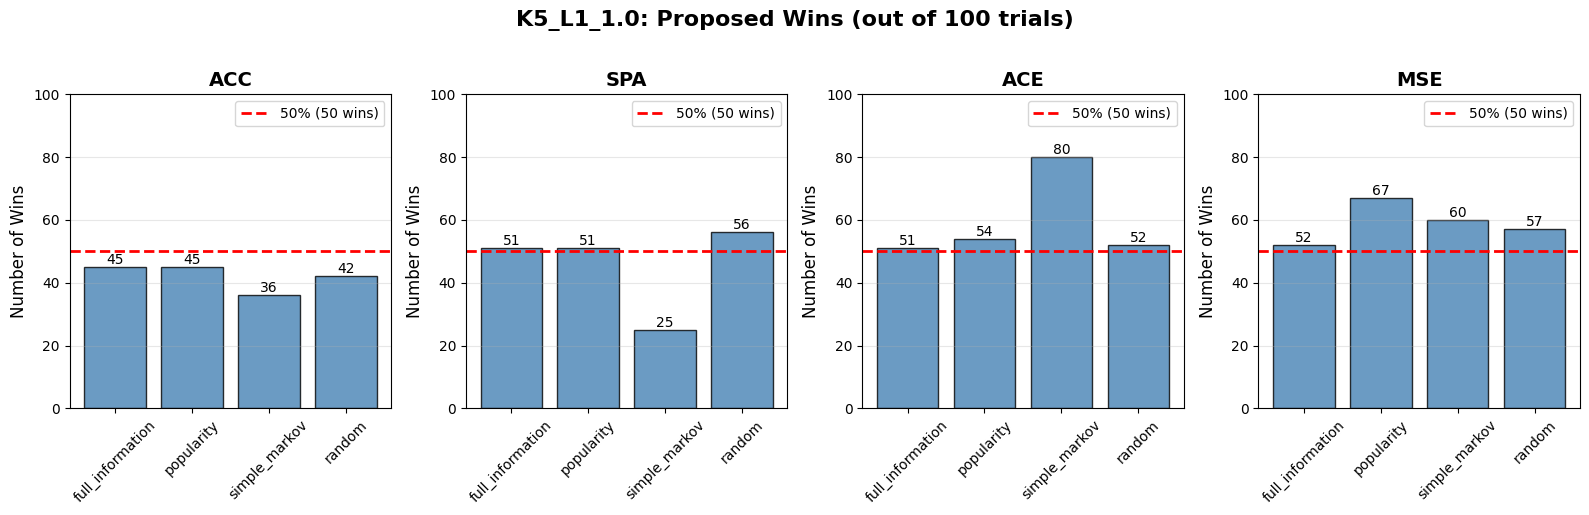

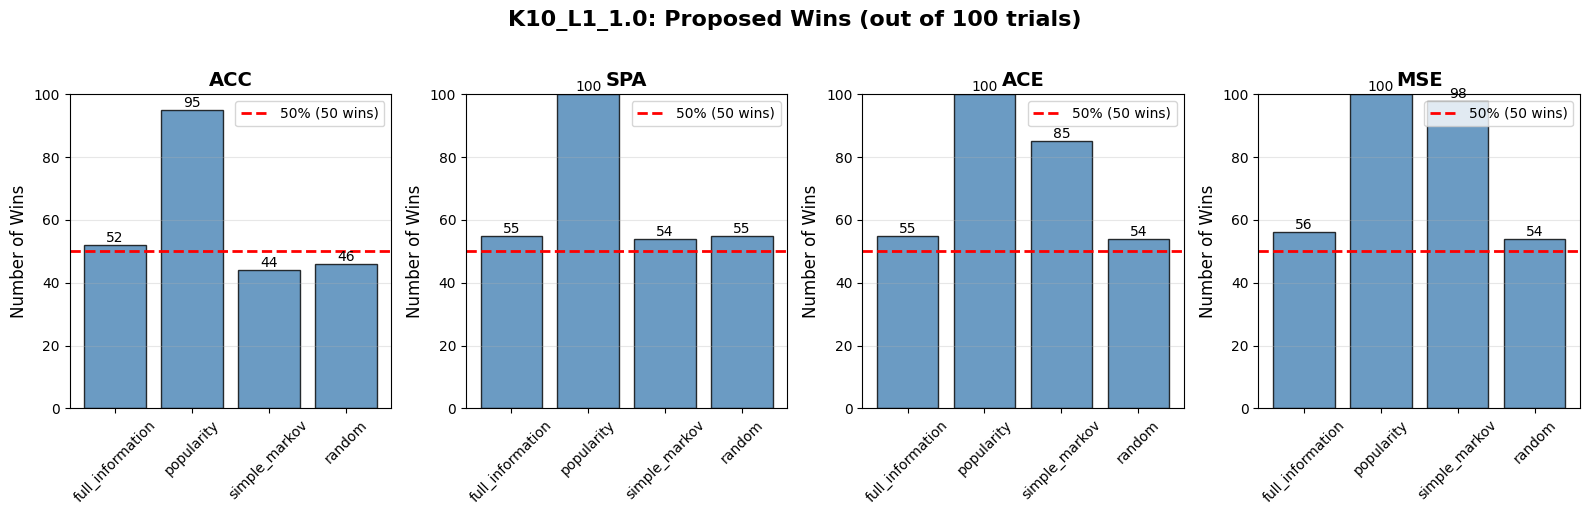

In [5]:
# Win counts bar chart
for dataset in df_wins['dataset'].unique():
    df_dataset = df_wins[df_wins['dataset'] == dataset]
    
    win_cols = [col for col in df_dataset.columns if col.endswith('_wins')]
    
    if not win_cols:
        continue
    
    fig, axes = plt.subplots(1, len(win_cols), figsize=(len(win_cols)*4, 5))
    
    if len(win_cols) == 1:
        axes = [axes]
    
    for idx, win_col in enumerate(win_cols):
        metric = win_col.replace('_wins', '')
        ax = axes[idx]
        
        baselines = df_dataset['baseline'].values
        wins = df_dataset[win_col].values
        n_trials = df_dataset['n_trials'].values[0]
        
        bars = ax.bar(baselines, wins, alpha=0.8, color='steelblue', edgecolor='black')
        ax.axhline(y=n_trials/2, color='red', linestyle='--', linewidth=2, label=f'50% ({n_trials//2} wins)')
        
        ax.set_ylabel('Number of Wins', fontsize=12)
        ax.set_title(f'{metric.upper()}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylim(0, n_trials)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontsize=10)
    
    fig.suptitle(f'{dataset.upper()}: Proposed Wins (out of {n_trials} trials)', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 5. Wilcoxon Test Results

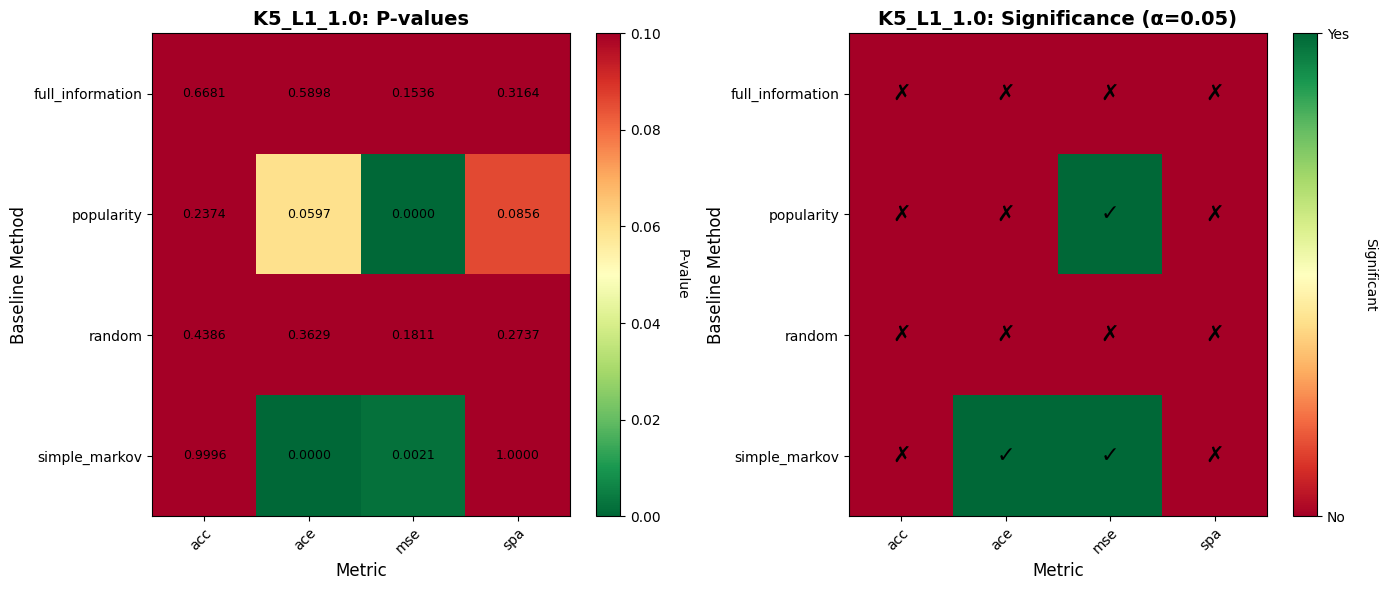


K5_L1_1.0 - Significance Summary:
  Significant results: 3 / 16 (18.8%)

  Significant cases:


,metric,baseline,p_value
7,mse,popularity,2.973374e-06
10,ace,simple_markov,1.753693e-14
11,mse,simple_markov,2.113626e-03


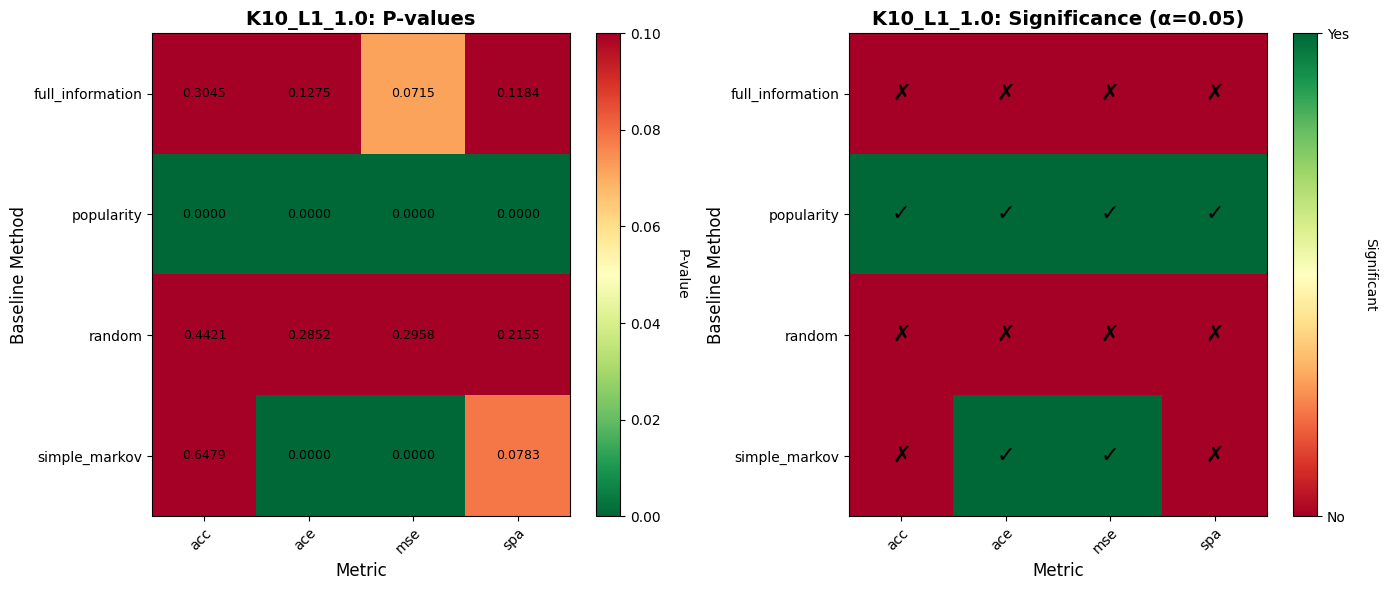


K10_L1_1.0 - Significance Summary:
  Significant results: 6 / 16 (37.5%)

  Significant cases:


,metric,baseline,p_value
20,acc,popularity,2.375213e-17
21,spa,popularity,1.948280e-18
22,ace,popularity,1.948280e-18
23,mse,popularity,1.948280e-18
26,ace,simple_markov,3.215658e-14
27,mse,simple_markov,4.133899e-18


In [6]:
# Wilcoxon test significance visualization
if not df_wilcoxon.empty:
    for dataset in df_wilcoxon['dataset'].unique():
        df_dataset = df_wilcoxon[df_wilcoxon['dataset'] == dataset]
        
        # Create pivot table for heatmap
        pivot_pvalue = df_dataset.pivot(index='baseline', columns='metric', values='p_value')
        pivot_significant = df_dataset.pivot(index='baseline', columns='metric', values='significant')
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # P-value heatmap
        ax1 = axes[0]
        im1 = ax1.imshow(pivot_pvalue.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.1)
        ax1.set_xticks(np.arange(len(pivot_pvalue.columns)))
        ax1.set_yticks(np.arange(len(pivot_pvalue.index)))
        ax1.set_xticklabels(pivot_pvalue.columns)
        ax1.set_yticklabels(pivot_pvalue.index)
        plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        
        # Add p-value annotations
        for i in range(len(pivot_pvalue.index)):
            for j in range(len(pivot_pvalue.columns)):
                val = pivot_pvalue.values[i, j]
                if not np.isnan(val):
                    text = ax1.text(j, i, f'{val:.4f}',
                                   ha="center", va="center", color="black", fontsize=9)
        
        ax1.set_title(f'{dataset.upper()}: P-values', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Metric', fontsize=12)
        ax1.set_ylabel('Baseline Method', fontsize=12)
        cbar1 = plt.colorbar(im1, ax=ax1)
        cbar1.set_label('P-value', rotation=270, labelpad=20)
        
        # Significance heatmap
        ax2 = axes[1]
        im2 = ax2.imshow(pivot_significant.values.astype(float), cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
        ax2.set_xticks(np.arange(len(pivot_significant.columns)))
        ax2.set_yticks(np.arange(len(pivot_significant.index)))
        ax2.set_xticklabels(pivot_significant.columns)
        ax2.set_yticklabels(pivot_significant.index)
        plt.setp(ax2.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        
        # Add significance annotations
        for i in range(len(pivot_significant.index)):
            for j in range(len(pivot_significant.columns)):
                val = pivot_significant.values[i, j]
                if not np.isnan(val):
                    symbol = '✓' if val else '✗'
                    text = ax2.text(j, i, symbol,
                                   ha="center", va="center", color="black", fontsize=16)
        
        ax2.set_title(f'{dataset.upper()}: Significance (α=0.05)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Metric', fontsize=12)
        ax2.set_ylabel('Baseline Method', fontsize=12)
        cbar2 = plt.colorbar(im2, ax=ax2, ticks=[0, 1])
        cbar2.set_label('Significant', rotation=270, labelpad=20)
        cbar2.set_ticklabels(['No', 'Yes'])
        
        plt.tight_layout()
        plt.show()
        
        # Summary statistics
        print(f"\n{dataset.upper()} - Significance Summary:")
        significant_count = df_dataset['significant'].sum()
        total_count = len(df_dataset)
        print(f"  Significant results: {significant_count} / {total_count} ({significant_count/total_count*100:.1f}%)")
        
        if significant_count > 0:
            print("\n  Significant cases:")
            display(df_dataset[df_dataset['significant']][['metric', 'baseline', 'p_value']])
else:
    print("No Wilcoxon test results available.")

## 6. Summary Table

In [7]:
# Create summary table
print("="*80)
print("SUMMARY")
print("="*80)

for dataset in df_stats['dataset'].unique():
    print(f"\n{dataset.upper()}:")
    print("-"*80)
    
    df_dataset_stats = df_stats[df_stats['dataset'] == dataset]
    df_dataset_wins = df_wins[df_wins['dataset'] == dataset]
    df_dataset_wilcoxon = df_wilcoxon[df_wilcoxon['dataset'] == dataset] if not df_wilcoxon.empty else pd.DataFrame()
    
    # Performance
    print("\nPerformance (Mean ± Std):")
    display(df_dataset_stats[['method', 'acc_mean', 'acc_std', 'spa_mean', 'spa_std', 
                               'ace_mean', 'ace_std', 'mse_mean', 'mse_std']])
    
    # Win rates
    if not df_dataset_wins.empty:
        print("\nWin Rates:")
        win_rate_cols = [col for col in df_dataset_wins.columns if col.endswith('_win_rate')]
        display(df_dataset_wins[['baseline'] + win_rate_cols])
    
    # Wilcoxon significance
    if not df_dataset_wilcoxon.empty:
        print("\nStatistical Significance:")
        sig_summary = df_dataset_wilcoxon.groupby('metric')['significant'].sum()
        print(f"  Significant results by metric:")
        display(sig_summary)

print("\n" + "="*80)

SUMMARY

K5_L1_1.0:
--------------------------------------------------------------------------------

Performance (Mean ± Std):


,method,acc_mean,acc_std,spa_mean,spa_std,ace_mean,ace_std,mse_mean,mse_std
0,proposed,0.733636,0.088208,0.776832,0.043587,0.411128,0.082081,0.073825,0.015415
1,full_information,0.740076,0.087595,0.776807,0.043587,0.411104,0.082102,0.073850,0.015437
2,popularity,0.728333,0.083253,0.775675,0.044897,0.414566,0.085565,0.076137,0.017019
3,simple_markov,0.767045,0.078673,0.797951,0.049723,1.396808,1.050524,0.079283,0.021902
4,random,0.732500,0.082965,0.776811,0.043590,0.411147,0.082130,0.073839,0.015429



Win Rates:


,baseline,acc_win_rate,spa_win_rate,ace_win_rate,mse_win_rate
0,full_information,0.45,0.51,0.51,0.52
1,popularity,0.45,0.51,0.54,0.67
2,simple_markov,0.36,0.25,0.80,0.60
3,random,0.42,0.56,0.52,0.57



Statistical Significance:
  Significant results by metric:


...

,method,acc_mean,acc_std,spa_mean,spa_std,ace_mean,ace_std,mse_mean,mse_std
5,proposed,0.675369,0.096406,0.688252,0.048882,0.467133,0.098471,0.074288,0.013480
6,full_information,0.669571,0.097582,0.688206,0.048894,0.467219,0.098411,0.074306,0.013448
7,popularity,0.556774,0.092030,0.654047,0.053546,0.545401,0.113044,0.093626,0.016246
8,simple_markov,0.676679,0.087665,0.683028,0.059312,1.695951,1.221318,0.096570,0.021047
9,random,0.675750,0.089622,0.688231,0.048932,0.467152,0.098464,0.074292,0.013476



Win Rates:


,baseline,acc_win_rate,spa_win_rate,ace_win_rate,mse_win_rate
4,full_information,0.52,0.55,0.55,0.56
5,popularity,0.95,1.00,1.00,1.00
6,simple_markov,0.44,0.54,0.85,0.98
7,random,0.46,0.55,0.54,0.54



Statistical Significance:
  Significant results by metric:


metric
acc    1
ace    2
mse    2
spa    1
Name: significant, dtype: int64